# Profundización en Estadística para Científicos de Datos  
##  Densidad conjunta continua: marginales, condicionales e independencia

**Objetivo de la sesión (práctico):**  
1) interpretar una densidad conjunta continua,  
2) calcular marginales y condicionales (analítico + verificación numérica),  
3) decidir independencia (criterio operativo),  
4) conectar todo con simulación y visualización.

> Convención: usaremos $f_{X,Y}(x,y)$ para densidad conjunta, $f_X(x)$ y $f_Y(y)$ para marginales, y $f_{Y|X}(y|x)$ para condicional.


In [ ]:
# --- Paquetes base (Colab) ---
import numpy as np
import matplotlib.pyplot as plt

# Si scipy está disponible, la usamos para integrar/validar; si no, seguimos con aproximaciones numéricas.
try:
    import scipy.integrate as integrate
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

np.random.seed(7)
print("SCIPY_OK =", SCIPY_OK)


SCIPY_OK = True


## 1. ¿Qué es una densidad conjunta continua?

Una función $f_{X,Y}(x,y)$ es una **densidad conjunta** si:

1. $f_{X,Y}(x,y) \ge 0$ para todo $(x,y)$.  
2. La probabilidad total es 1:  
$$
\int_{\mathbb{R}}\int_{\mathbb{R}} f_{X,Y}(x,y)\,dy\,dx = 1.
$$

Y para cualquier región $A$ en el plano,
$$
P((X,Y)\in A)=\iint_A f_{X,Y}(x,y)\,dx\,dy.
$$

**Traducción a Ciencia de Datos:** una densidad conjunta describe cómo “vive” la masa/probabilidad en el plano (o en $\mathbb{R}^p$).  
Lo multivariado empieza cuando esa masa **no se separa** en producto de marginales.


## 2. Ejemplo trabajado: distribución uniforme en un triángulo

Definimos el soporte:
$$
\mathcal{T}=\{(x,y): x\ge 0,\ y\ge 0,\ x+y\le 1\}.
$$

Proponemos:
$$
f_{X,Y}(x,y)=c\,\mathbf{1}_{\mathcal{T}}(x,y).
$$

Como el área del triángulo es $\tfrac{1}{2}$, para que integre a 1 debe ser:
$$
c\cdot \tfrac{1}{2} = 1 \Rightarrow c=2.
$$

Es decir,
$$
f_{X,Y}(x,y)=2\,\mathbf{1}_{\{x\ge0,\ y\ge0,\ x+y\le1\}}.
$$


In [ ]:
def f_xy_triangle(x, y):
    # f(x,y)=2 dentro del triángulo x>=0,y>=0,x+y<=1; 0 en otro caso
    cond = (x >= 0) & (y >= 0) & (x + y <= 1)
    return np.where(cond, 2.0, 0.0)

# Verificación numérica de normalización (integral) si hay scipy
if SCIPY_OK:
    val, err = integrate.dblquad(lambda yy, xx: f_xy_triangle(xx, yy), 0, 1, lambda xx: 0, lambda xx: 1-xx)
    print("Integral sobre el triángulo =", val, " (error aprox =", err, ")")
else:
    print("Sin scipy: validamos por simulación/Monte Carlo más abajo.")


Integral sobre el triángulo = 1.0  (error aprox = 2.2156245316493716e-14 )


### Visualización: soporte de la densidad

En este ejemplo, la densidad es constante (2) dentro del triángulo y 0 fuera.  
Lo importante no es el “valor 2”, sino el **soporte**.


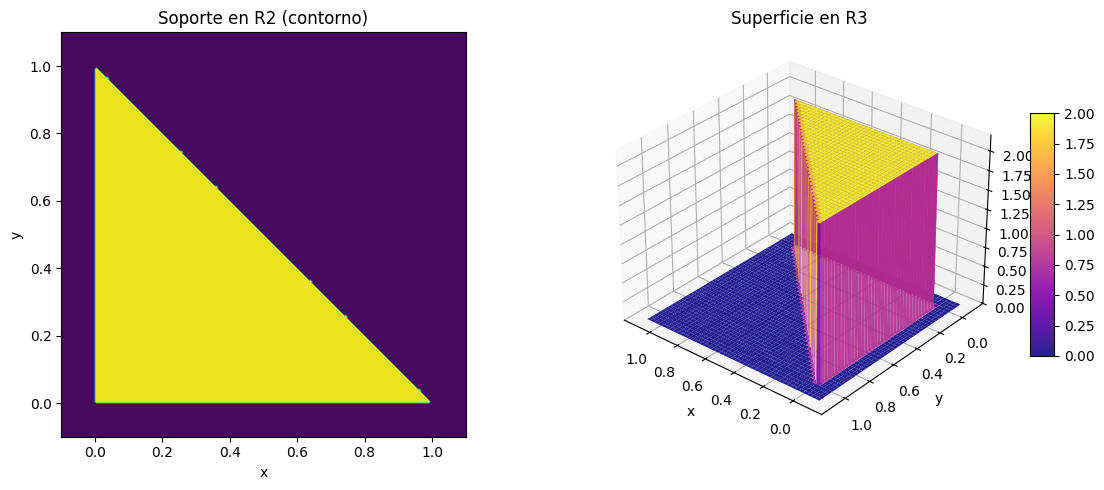

In [ ]:
# @title
from mpl_toolkits.mplot3d import Axes3D

grid = 220
x = np.linspace(-0.1, 1.1, grid)
y = np.linspace(-0.1, 1.1, grid)
X, Y = np.meshgrid(x, y)
Z = f_xy_triangle(X, Y)

fig = plt.figure(figsize=(12,5))

# ---- Subplot 1: soporte en R2 ----
ax1 = fig.add_subplot(1, 2, 1)
cont = ax1.contourf(X, Y, Z, levels=20, cmap="viridis")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Soporte en R2 (contorno)")
ax1.set_aspect("equal")

# ---- Subplot 2: superficie en R3 ----
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_surface(
    X, Y, Z,
    cmap="plasma",        # mejor contraste
    edgecolor='none',
    alpha=0.9
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")
ax2.set_zlim(0, 2.2)      # fija escala vertical
ax2.set_title("Superficie en R3")
ax2.view_init(elev=30, azim=130)

fig.colorbar(surf, ax=ax2, shrink=0.6, aspect=10)

plt.tight_layout()
plt.show()


## 3. Marginales: $f_X(x)$ y $f_Y(y)$

Por definición,
$$
f_X(x)=\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dy,\qquad
f_Y(y)=\int_{-\infty}^{\infty} f_{X,Y}(x,y)\,dx.
$$

En el triángulo, para un $x$ fijo con $0\le x\le 1$, el $y$ permitido va de $0$ a $1-x$. Entonces:
$$
f_X(x)=\int_0^{1-x} 2\,dy = 2(1-x),\quad 0\le x\le 1,
$$
y 0 fuera. Por simetría:
$$
f_Y(y)=2(1-y),\quad 0\le y\le 1.
$$


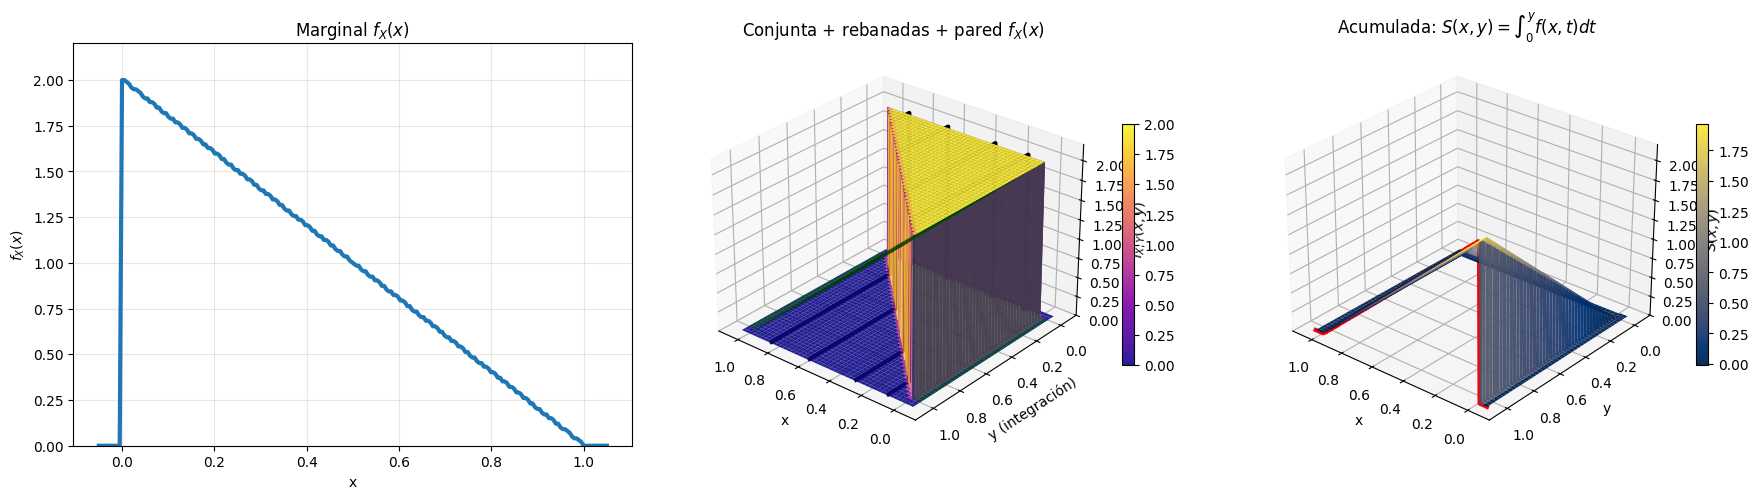

In [ ]:
# @title
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# ----- Malla -----
grid = 220
x = np.linspace(-0.05, 1.05, grid)
y = np.linspace(-0.05, 1.05, grid)
X, Y = np.meshgrid(x, y)
Z = f_xy_triangle(X, Y)

# ----- Marginal numérica f_X(x) -----
fx_num = np.trapezoid(Z, y, axis=0)

# ----- Acumulada correcta S(x,y)=∫_0^y f(x,t)dt -----
dy = y[1] - y[0]
S = np.cumsum(Z, axis=0) * dy

# Forzamos que S(x,0)=0
y0_idx = np.argmin(np.abs(y - 0.0))
S = S - S[y0_idx, :]

# ----- Figura -----
fig = plt.figure(figsize=(18,5))

# ========================
# 1) Marginal 2D
# ========================
ax1 = fig.add_subplot(1,3,1)
ax1.plot(x, fx_num, linewidth=3)
ax1.set_title("Marginal $f_X(x)$")
ax1.set_xlabel("x")
ax1.set_ylabel("$f_X(x)$")
ax1.set_ylim(0,2.2)
ax1.grid(True, alpha=0.3)

# ========================
# 2) Conjunta + rebanadas
# ========================
ax2 = fig.add_subplot(1,3,2, projection='3d')

surf = ax2.plot_surface(
    X, Y, Z,
    cmap="plasma",
    edgecolor='none',
    alpha=0.9
)

# Rebanadas verticales reales
xs_demo = [0.1, 0.3, 0.6, 0.85]
for x0 in xs_demo:
    j = np.argmin(np.abs(x - x0))
    ax2.plot(
        np.full_like(y, x[j]),
        y,
        Z[:, j] + 0.02,   # pequeño lift para que se vea
        color='black',
        linewidth=3
    )

# Pared marginal correcta
Y_wall = np.linspace(0, 1, 2)
X_wall, Y_wall = np.meshgrid(x, Y_wall)
Z_wall = np.tile(fx_num, (2,1))

ax2.plot_surface(
    X_wall,
    Y_wall,
    Z_wall,
    color='green',
    alpha=0.5
)

ax2.set_xlabel("x")
ax2.set_ylabel("y (integración)")
ax2.set_zlabel("$f_{X,Y}(x,y)$")
ax2.set_zlim(0,2.2)
ax2.set_title("Conjunta + rebanadas + pared $f_X(x)$")
ax2.view_init(elev=28, azim=130)

fig.colorbar(surf, ax=ax2, shrink=0.6)

# ========================
# 3) Acumulada S(x,y)
# ========================
ax3 = fig.add_subplot(1,3,3, projection='3d')

surf2 = ax3.plot_surface(
    X, Y, S,
    cmap="cividis",
    edgecolor='none',
    alpha=0.95
)

# Línea superior = marginal
ax3.plot(
    x,
    np.full_like(x, y.max()),
    S[-1, :],
    color='red',
    linewidth=3
)

ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("$S(x,y)$")
ax3.set_zlim(0,2.2)
ax3.set_title("Acumulada: $S(x,y)=\\int_0^y f(x,t)dt$")
ax3.view_init(elev=28, azim=130)

fig.colorbar(surf2, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()

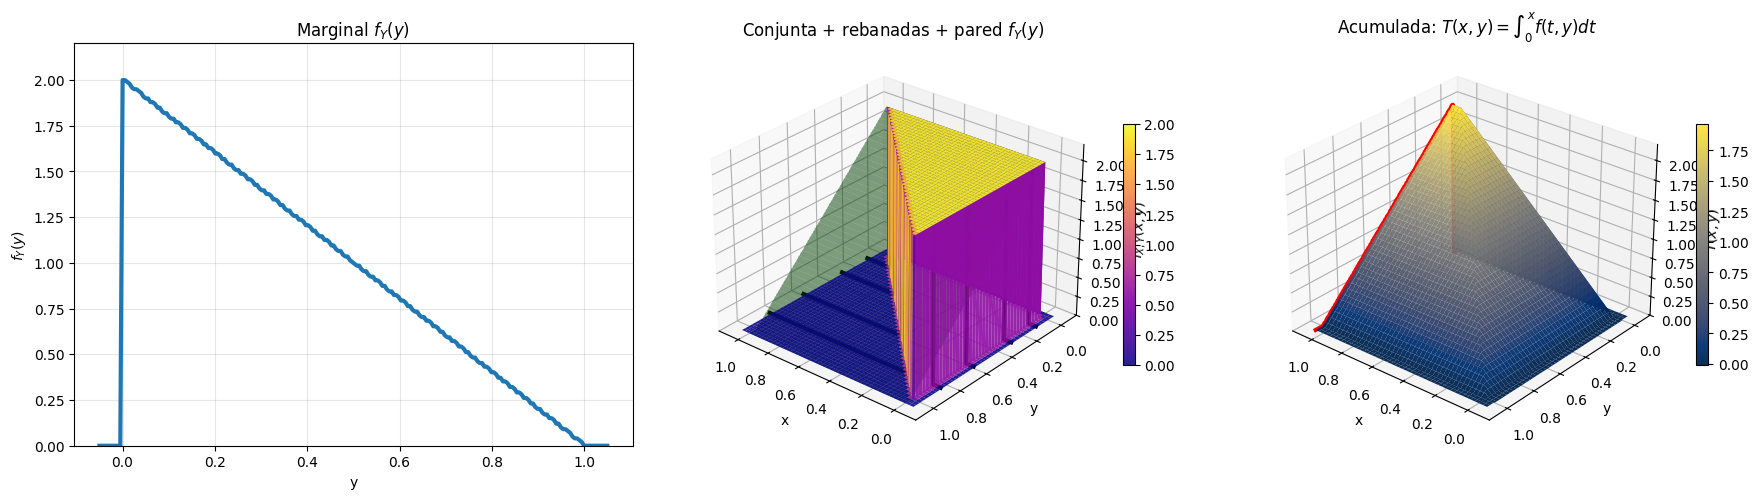

In [ ]:
# @title
# ----- Marginal f_Y(y) -----
fy_num = np.trapezoid(Z, x, axis=1)

# ----- Acumulada T(x,y)=∫_0^x f(t,y)dt -----
dx = x[1] - x[0]
T = np.cumsum(Z, axis=1) * dx

x0_idx = np.argmin(np.abs(x - 0.0))
T = T - T[:, x0_idx][:,None]

fig = plt.figure(figsize=(18,5))

# ========================
# 1) Marginal 2D
# ========================
ax1 = fig.add_subplot(1,3,1)
ax1.plot(y, fy_num, linewidth=3)
ax1.set_title("Marginal $f_Y(y)$")
ax1.set_xlabel("y")
ax1.set_ylabel("$f_Y(y)$")
ax1.set_ylim(0,2.2)
ax1.grid(True, alpha=0.3)

# ========================
# 2) Conjunta + rebanadas horizontales
# ========================
ax2 = fig.add_subplot(1,3,2, projection='3d')

surf = ax2.plot_surface(
    X, Y, Z,
    cmap="plasma",
    edgecolor='none',
    alpha=0.9
)

ys_demo = [0.1, 0.3, 0.6, 0.85]
for y0 in ys_demo:
    i = np.argmin(np.abs(y - y0))
    ax2.plot(
        x,
        np.full_like(x, y[i]),
        Z[i, :] + 0.02,
        color='black',
        linewidth=3
    )

# Pared marginal
X_wall = np.linspace(0, 1, 2)
X_wall, Y_wall = np.meshgrid(X_wall, y)
Z_wall = np.tile(fy_num[:,None], (1,2))

ax2.plot_surface(
    X_wall,
    Y_wall,
    Z_wall,
    color='green',
    alpha=0.5
)

ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("$f_{X,Y}(x,y)$")
ax2.set_zlim(0,2.2)
ax2.set_title("Conjunta + rebanadas + pared $f_Y(y)$")
ax2.view_init(elev=28, azim=130)

fig.colorbar(surf, ax=ax2, shrink=0.6)

# ========================
# 3) Acumulada en x
# ========================
ax3 = fig.add_subplot(1,3,3, projection='3d')

surf2 = ax3.plot_surface(
    X, Y, T,
    cmap="cividis",
    edgecolor='none',
    alpha=0.95
)

ax3.plot(
    np.full_like(y, x.max()),
    y,
    T[:, -1],
    color='red',
    linewidth=3
)

ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("$T(x,y)$")
ax3.set_zlim(0,2.2)
ax3.set_title("Acumulada: $T(x,y)=\\int_0^x f(t,y)dt$")
ax3.view_init(elev=28, azim=130)

fig.colorbar(surf2, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.show()

## 4. Condicionales: $f_{Y|X}(y|x)$

Por definición (cuando $f_X(x)>0$):
$$
f_{Y|X}(y|x)=\frac{f_{X,Y}(x,y)}{f_X(x)}.
$$

En el triángulo, para $0\le x<1$ y $0\le y\le 1-x$:
$$
f_{Y|X}(y|x)=\frac{2}{2(1-x)}=\frac{1}{1-x}.
$$

Es decir: **dado $X=x$**, Y es uniforme en $[0,1-x]$.


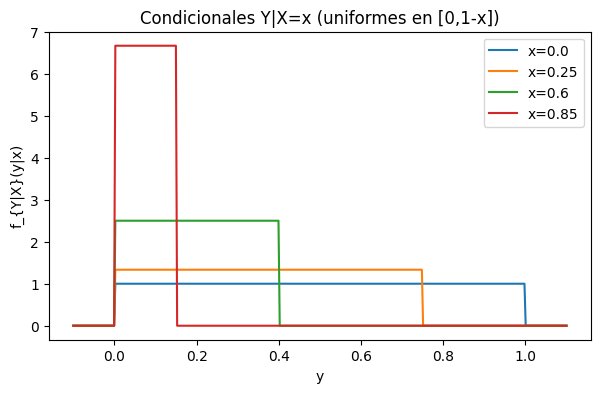

In [ ]:
def f_y_given_x_triangle(y, x):
    y = np.asarray(y)
    x = float(x)
    if not (0 <= x < 1):
        return np.zeros_like(y, dtype=float)
    out = np.zeros_like(y, dtype=float)
    m = (0 <= y) & (y <= 1-x)
    out[m] = 1.0/(1.0-x)
    return out

xs = [0.0, 0.25, 0.6, 0.85]
yy = np.linspace(-0.1, 1.1, 400)

plt.figure(figsize=(7,4))
for x0 in xs:
    plt.plot(yy, f_y_given_x_triangle(yy, x0), label=f"x={x0}")
plt.xlabel("y")
plt.ylabel("f_{Y|X}(y|x)")
plt.title("Condicionales Y|X=x (uniformes en [0,1-x])")
plt.legend()
plt.show()


## 5. Independencia: criterio operativo

$X$ y $Y$ son independientes si y solo si:
$$
f_{X,Y}(x,y)=f_X(x)f_Y(y) \quad \text{para todo } (x,y).
$$

**En este ejemplo NO lo son.**  
Intuición: si $X$ sale grande, obliga a que $Y$ sea pequeño (porque $X+Y\le 1$). Esa es dependencia “de soporte”.


## 6. Momentos, covarianza y correlación (derivación analítica)

Ya hemos encontrado las marginales:

$$
f_X(x)=2(1-x), \quad 0\le x\le1,
$$

$$
f_Y(y)=2(1-y), \quad 0\le y\le1.
$$

A partir de ellas podemos calcular los momentos.

---

### 6.1 Esperanzas marginales

Por definición,

$$
E[X]=\int_0^1 x f_X(x)\,dx
$$

$$
= \int_0^1 2x(1-x)\,dx
$$

$$
= 2\int_0^1 (x - x^2)\,dx
$$

$$
= 2\left(\frac{1}{2}-\frac{1}{3}\right)
$$

$$
= \frac{1}{3}.
$$

Por simetría,

$$
E[Y]=\frac{1}{3}.
$$

---

### 6.2 Segundo momento y varianza

$$
E[X^2]=\int_0^1 x^2 f_X(x)\,dx
$$

$$
= \int_0^1 2x^2(1-x)\,dx
$$

$$
= 2\int_0^1 (x^2 - x^3)\,dx
$$

$$
= 2\left(\frac{1}{3}-\frac{1}{4}\right)
$$

$$
= \frac{1}{6}.
$$

Entonces,

$$
Var(X)=E[X^2]-(E[X])^2
$$

$$
= \frac{1}{6}-\frac{1}{9}
$$

$$
= \frac{1}{18}.
$$

Por simetría,

$$
Var(Y)=\frac{1}{18}.
$$

---

### 6.3 Momento cruzado

Por definición, el **momento cruzado de orden (1,1)** es

$$
E[XY]=\int_{-\infty}^{\infty}\int_{-\infty}^{\infty} xy\, f_{X,Y}(x,y)\,dy\,dx.
$$

En nuestro caso, $f_{X,Y}(x,y)=2$ en el triángulo $0\le x\le1,\; 0\le y\le 1-x$ y 0 fuera, por lo que

$$
E[XY]=\int_0^1 \int_0^{1-x} xy\cdot 2\,dy\,dx
=\int_0^1 \int_0^{1-x} 2xy\,dy\,dx.
$$

Integrando primero en $y$:

$$
= \int_0^1 2x\left[\frac{y^2}{2}\right]_{0}^{1-x}\,dx
$$

$$
= \int_0^1 x(1-x)^2\,dx
$$

$$
= \int_0^1 (x - 2x^2 + x^3)\,dx
$$

$$
= \frac{1}{2}-\frac{2}{3}+\frac{1}{4}
$$

$$
= \frac{1}{12}.
$$

---

### 6.4 Covarianza

$$
Cov(X,Y)=E[XY]-E[X]E[Y]
$$

$$
= \frac{1}{12}-\frac{1}{9}
$$

$$
= -\frac{1}{36}.
$$

La covarianza es negativa porque el soporte impone la restricción $x+y\le1$: si $X$ aumenta, el espacio posible para $Y$ disminuye.

---

### 6.5 Correlación

$$
\rho=\frac{Cov(X,Y)}{\sqrt{Var(X)Var(Y)}}
$$

$$
= \frac{-1/36}{\sqrt{(1/18)(1/18)}}
$$

$$
= -\frac{1}{2}.
$$

---

### Resumen teórico

$$
E[X]=E[Y]=\frac{1}{3}
$$

$$
Var(X)=Var(Y)=\frac{1}{18}
$$

$$
Cov(X,Y)=-\frac{1}{36}
$$

$$
\rho=-\frac{1}{2}
$$

En la siguiente sección verificaremos empíricamente estos valores mediante simulación.

## 7. Simulación desde el triángulo (verificación)

Método rápido:
1) tomar $(U,V)$ i.i.d. uniformes en $[0,1]$.  
2) si $U+V>1$, reflejar: $(U,V)\leftarrow (1-U,1-V)$.  
Entonces $(X,Y)=(U,V)$ queda uniforme en el triángulo.


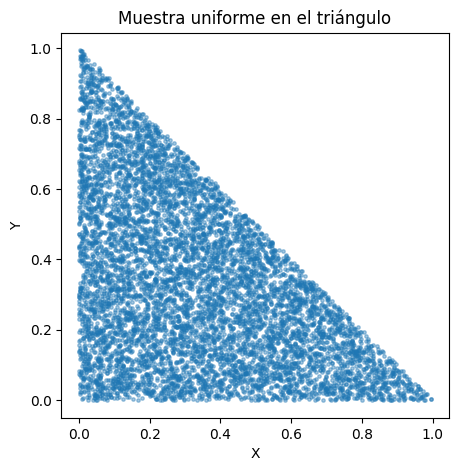

Media muestral de X: 0.33395405279915025
Media muestral de Y: 0.333388525358179
Varianza muestral de X: 0.056017068522983764
Varianza muestral de Y: 0.05535467117684722
Covarianza muestral:
 [[ 0.05601707 -0.02753936]
 [-0.02753936  0.05535467]]
Correlación muestral: -0.4945571565652244


In [ ]:
# @title
def sample_uniform_triangle(n):
    U = np.random.rand(n)
    V = np.random.rand(n)
    mask = (U + V > 1)
    U[mask] = 1 - U[mask]
    V[mask] = 1 - V[mask]
    return U, V

n = 8000
X_s, Y_s = sample_uniform_triangle(n)

plt.figure(figsize=(5,5))
plt.scatter(X_s, Y_s, s=6, alpha=0.4)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Muestra uniforme en el triángulo")
plt.axis("equal")
plt.show()

print("Media muestral de X:", X_s.mean())
print("Media muestral de Y:", Y_s.mean())

print("Varianza muestral de X:", X_s.var(ddof=1))
print("Varianza muestral de Y:", Y_s.var(ddof=1))

print("Covarianza muestral:\n", np.cov(X_s, Y_s))
print("Correlación muestral:", np.corrcoef(X_s, Y_s)[0,1])


## 7. Cierre de sesión (lo que debes poder hacer)

1) leer una densidad conjunta y describir correctamente su soporte,  
2) calcular las marginales $f_X$ y $f_Y$ por integración,  
3) construir la condicional $f_{Y|X}(y|x)$ como cociente y entenderla como “rebanada normalizada”,  
4) decidir independencia usando el criterio $f_{X,Y}=f_X f_Y$,  
5) calcular momentos a partir de las marginales y de la conjunta: $E[X]$, $Var(X)$, $E[XY]$, $Cov(X,Y)$ y $\rho$,  
6) verificar empíricamente mediante simulación: nube de puntos, medias muestrales, varianzas, covarianza y correlación.


## Ejercicios propuestos (Tarea)

> En cada ejercicio, describa primero el **soporte** (la región donde la densidad es positiva) antes de integrar.

---

### Ejercicio 1 — Densidad conjunta en un rectángulo (estructura completa)

Sea $(X,Y)$ con densidad conjunta

$$
f_{X,Y}(x,y)=
\begin{cases}
2x, & 0\le x\le 1,\ 0\le y\le 1,\\
0, & \text{en otro caso}.
\end{cases}
$$

1. Verifique que es una densidad válida.  
2. Calcule las marginales $f_X(x)$ y $f_Y(y)$.  
3. Construya la condicional $f_{Y|X}(y|x)$ e interprete su forma.  
4. Calcule $E[X]$, $Var(X)$, $E[XY]$, $Cov(X,Y)$ y $\rho$.  
5. Decida si $X$ y $Y$ son independientes usando el criterio formal.

---

### Ejercicio 2 — Soporte triangular alternativo (dependencia estructural)

Sea $(X,Y)$ con densidad conjunta

$$
f_{X,Y}(x,y)=
\begin{cases}
c, & 0\le y\le x\le 1,\\
0, & \text{en otro caso}.
\end{cases}
$$

1. Encuentre la constante $c$.  
2. Calcule $f_X(x)$ y $f_Y(y)$.  
3. Construya $f_{Y|X}(y|x)$ e interprete su distribución.  
4. Calcule $E[X]$, $E[Y]$ y determine el signo de $Cov(X,Y)$.  
5. Explique, usando el soporte, por qué hay o no dependencia.

---

### Ejercicio 3 — Dependencia no lineal con correlación nula

Sea $X\sim \text{Unif}(-1,1)$ y defina $Y=X^2$.

1. Argumente por qué $X$ y $Y$ no son independientes.  
2. Calcule analíticamente $E[X]$, $E[Y]$ y $Cov(X,Y)$.  
3. Concluya el valor de la correlación.  
4. Verifique mediante simulación (nube de puntos + correlación muestral).  
5. Explique por qué correlación 0 no implica independencia.

---

### Ejercicio 4 — Independencia en familia exponencial

Sea $(X,Y)$ con densidad conjunta

$$
f_{X,Y}(x,y)=
\begin{cases}
k\,e^{-x}e^{-y}, & x>0,\ y>0,\\
0, & \text{en otro caso}.
\end{cases}
$$

1. Determine $k$.  
2. Calcule $f_X(x)$ y $f_Y(y)$.  
3. Construya $f_{Y|X}(y|x)$ y determine si depende de $x$.  
4. Calcule $E[X]$, $Var(X)$, $E[Y]$, $Var(Y)$.  
5. Decida independencia formalmente.

---

### Ejercicio 5 — Lectura geométrica y momento cruzado

Use la densidad del **Ejercicio 2**.

1. Calcule $E[XY]$.  
2. Determine $Cov(X,Y)$.  
3. Interprete el signo de la covarianza a partir del soporte.  
4. Compare con el caso trabajado en clase (triángulo $x+y\le1$).

---

### Ejercicio 6 — Mini-reto aplicado (modelo + simulación)

Considere el modelo del **Ejercicio 1**.

1. Simule $(X,Y)$ en Colab.  
2. Estime empíricamente medias, varianzas, covarianza y correlación.  
3. Compare los valores muestrales con los valores teóricos.  
4. Interprete los resultados en términos de dependencia estructural.